### Analysis of PFC data from Mante et al 2013

In [1]:
import pandas as pd
import numpy as np
import torch
from latent_net import *

## Load PFC data and reshape int 3d array for latent circuit model fitting

In [2]:
## Load PFC pandas data frame
train = pd.read_pickle("Data/Mante/Monkey_ar/pfc_trajectory_ar.pkl")  

In [3]:
# Reshape responses into 3d array of shape trials x time x neurons and collect trial conditions 
n_boot = 5 # Number of bootstraps used when estimating mean trajectories
k = 72 # Number of experimental conditions
t = train.response.values[0].shape[1] # Time steps
n = train.response.values[0].shape[0] # Number of neurons
flattened_conditions = []
y = torch.zeros(n_boot * k, t, n)
trial = 0
for index, row in train.iterrows():
    y[trial,:,:] = torch.tensor(row['response']).float().t()
    trial+=1
    flattened_conditions.append([row['context'],
                                 row['stim_dir'],
                                 row['stim_col2dir'],
                                 row['correct'] * row['choice']])

In [4]:
# PFC responses correspond to 15 time points after stimulus onset. To align with responses from latent circuit (simulated for 150 time points
# we pad the PFC responses with zeros. 
y_sub = torch.zeros((y.shape[0],150,y.shape[2]))
y_sub[:,75::5,:] = y
y = y_sub

## Construct inputs and targets for latent net

In [5]:
# Here generate inputs and targets for the latent circuit model for each corresponding trial in the PFC data. We the
# stimulus coherence and context cue on each trial to construct inputs and the monkey's choice to construct targets for the
# latent circuit model output. Model fitting is restricted to correct choices. 
def generate_input_target_stream(context, motion_coh, color_coh, alpha, baseline, sigma_in, n_t, cue_on, cue_off,
                                 stim_on, stim_off, dec_on, dec_off, data_on, qui_on, qui_off):

    n_in = 6

    # Transform coherence to signal
    motion_r = (1 + motion_coh) / 2
    motion_l = 1 - motion_r
    color_r = (1 + color_coh) / 2
    color_l = 1 - color_r

    # Cue input stream
    cue_input = np.zeros([n_t, n_in])
    if context == "motion":
        cue_input[cue_on:cue_off, 0] = 1.2 * np.ones(
            [cue_off - cue_on, 1]).squeeze()
    else:
        cue_input[cue_on:cue_off, 1] = 1.2 * np.ones(
            [cue_off - cue_on, 1]).squeeze()

    # Motion input stream
    motion_input = np.zeros([n_t, n_in])
    motion_input[stim_on:stim_off, 2] = motion_r * np.ones([stim_off - stim_on])
    motion_input[stim_on:stim_off, 3] = motion_l * np.ones([stim_off - stim_on])

    # Color input stream
    color_input = np.zeros([n_t, n_in])
    color_input[stim_on:stim_off, 4] = color_r * np.ones([stim_off - stim_on])
    color_input[stim_on:stim_off, 5] = color_l * np.ones([stim_off - stim_on])

    # Noise
    noise = np.sqrt(2 / alpha * sigma_in * sigma_in) * np.random.multivariate_normal(
        [0, 0, 0, 0, 0, 0], np.eye(n_in), n_t)

    # Baseline
    baseline = baseline * np.ones([n_t, n_in])

    # Input stream is rectified sum of baseline, task and noise signals.
    input_stream = np.maximum(baseline + cue_input + motion_input + color_input + noise, 0)

    # Target stream
    target_stream = 0.2 * np.ones([n_t, 2])
    if (context == "motion" and motion_coh > 0) or (context == "color" and color_coh > 0):
        target_stream[dec_on:dec_off, 0] = 1.2 * np.ones([dec_off - dec_on, 1]).squeeze()
        target_stream[dec_on:dec_off, 1] = 0.2 * np.ones([dec_off - dec_on, 1]).squeeze()
    else:
        target_stream[dec_on:dec_off, 0] = 0.2 * np.ones([dec_off - dec_on, 1]).squeeze()
        target_stream[dec_on:dec_off, 1] = 1.2 * np.ones([dec_off - dec_on, 1]).squeeze()

    return input_stream, target_stream


In [6]:
trial_events = {'n_t': 150,
                'cue_on': 0,
                'cue_off': 150,
                'stim_on': 75,
                'stim_off': 150,
                'dec_on': 125,
                'dec_off': 150,
                'data_on': 75,
                'qui_on': 0,
                'qui_off': 0}

u = []
z = []
alpha = 0.2
for condition in flattened_conditions:
    inputs, targets = generate_input_target_stream(condition[0],
                                                   condition[1],
                                                   condition[2],
                                                   alpha=alpha,
                                                   sigma_in=0.01,
                                                   baseline=0.2,
                                                   **trial_events)
    u.append(inputs)
    z.append(targets)

# Inputs and targets for latent circuit model
u = torch.tensor(np.stack(u, axis=0)).float()
z = torch.tensor(np.stack(z, axis=0)).float()


## Fit latent net

In [7]:
# Because PFC data corresponds to only 15 time steps after stimulus onset, we use a mask to only penalize errors for these time points. 
y_mask = torch.zeros((u.shape[0],u.shape[1],y.shape[2]))
y_mask[:,75::5,:]=1

In [13]:
# Fit latent circuit model
latent_net = LatentNet(n=8, N=483 ,input_size=6, n_trials = u.shape[0],sigma_rec = 0.15)

loss_history = latent_net.fit(u,z,y,epochs = 1000,lr = .02,l_y = 1,weight_decay = 0.001,y_mask = y_mask)

Epoch: 0/1000............. mse_z: 0.2130 nmse_y: 1.0221
Epoch: 10/1000............. mse_z: 0.1535 nmse_y: 0.9690
Epoch: 20/1000............. mse_z: 0.1489 nmse_y: 0.9413
Epoch: 30/1000............. mse_z: 0.1432 nmse_y: 0.9358
Epoch: 40/1000............. mse_z: 0.1405 nmse_y: 0.9129
Epoch: 50/1000............. mse_z: 0.1328 nmse_y: 0.8696
Epoch: 60/1000............. mse_z: 0.1123 nmse_y: 0.8390
Epoch: 70/1000............. mse_z: 0.0983 nmse_y: 0.8126
Epoch: 80/1000............. mse_z: 0.0946 nmse_y: 0.8116
Epoch: 90/1000............. mse_z: 0.0881 nmse_y: 0.8094
Epoch: 100/1000............. mse_z: 0.0840 nmse_y: 0.8122
Epoch: 110/1000............. mse_z: 0.0811 nmse_y: 0.8136
Epoch: 120/1000............. mse_z: 0.0773 nmse_y: 0.8068
Epoch: 130/1000............. mse_z: 0.0744 nmse_y: 0.8081
Epoch: 140/1000............. mse_z: 0.0705 nmse_y: 0.8040
Epoch: 150/1000............. mse_z: 0.0649 nmse_y: 0.8020
Epoch: 160/1000............. mse_z: 0.0830 nmse_y: 0.8186
Epoch: 170/1000..........

## Analyze fitted latent circuit

<Axes: >

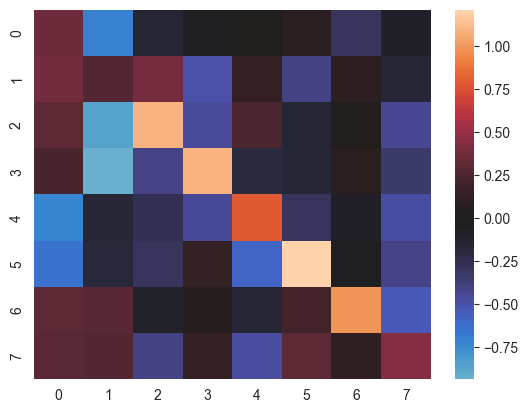

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.heatmap(latent_net.recurrent_layer.weight.data.cpu().numpy(), center=0)

In [16]:
x = latent_net(u)

In [17]:
# Reshape latent circuit responses into pandas dataframe (this can take a minute or two)
rows = []
for k in range(x.shape[0]):
    for t in range(x.shape[1]):
        for node in range(x.shape[2]):
            rows.append({'k':k,
                         'context':flattened_conditions[k][0],
                         'motion_coh': flattened_conditions[k][1],
                         'color_coh': flattened_conditions[k][2],
                         'correct_choice': flattened_conditions[k][3],
                         'x_context': x[k,t,1].item() - x[k,t,0].item(),
                         'x_motion': x[k,t,3].item() - x[k,t,2].item(),
                         'x_color': x[k,t,5].item() - x[k,t,4].item(),
                         'x_choice': x[k,t,7].item() - x[k,t,6].item(),
                         't': t})
            
latent_df = pd.DataFrame(rows)

In [18]:
# Project PFC responses onto columns of Q and reshape into pandas dataframe 
rows = []
q = latent_net.q
y_proj = y @ q.t()
y_proj = y_proj[:,75::5,:]
for k in range(y_proj.shape[0]):
    for t in range(y_proj.shape[1]):
        for node in range(y_proj.shape[2]):
            rows.append({'k':k,
                         'context':flattened_conditions[k][0],
                         'motion_coh': flattened_conditions[k][1],
                         'color_coh': flattened_conditions[k][2],
                         'correct_choice': flattened_conditions[k][3],
                         'x_context': y_proj[k,t,1].item() - y_proj[k,t,0].item(),
                         'x_motion': y_proj[k,t,3].item() - y_proj[k,t,2].item(),
                         'x_color': y_proj[k,t,5].item() - y_proj[k,t,4].item(),
                         'x_choice': y_proj[k,t,7].item() - y_proj[k,t,6].item(),
                         't': t})
            
pfc_df = pd.DataFrame(rows)

<Axes: xlabel='t', ylabel='x_motion'>

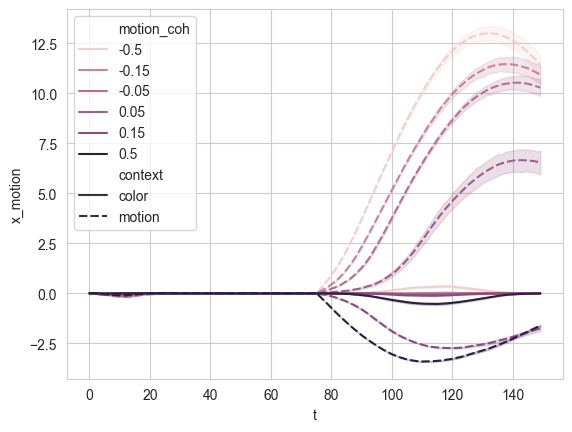

In [19]:
# Plot latents
plt.figure()
sns.lineplot(data = latent_df, x = 't',y = 'x_motion',hue = 'motion_coh',style = 'context')

<Axes: xlabel='t', ylabel='x_motion'>

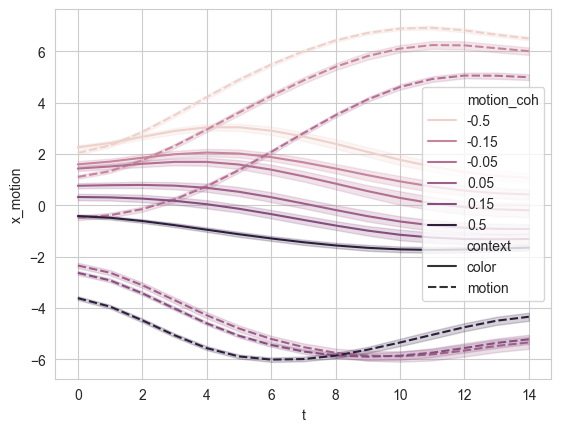

In [20]:
# Plot projected PFC responses. 
plt.figure()
sns.lineplot(data = pfc_df, x = 't',y = 'x_motion',hue = 'motion_coh',style = 'context')